In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CBCT_to_sCT_Project

Mounted at /content/drive
/content/drive/MyDrive/CBCT_to_sCT_Project


In [2]:
!pip install -q SimpleITK pandas matplotlib numpy torch torchvision segmentation-models-pytorch scikit-image tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00


In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from skimage.metrics import structural_similarity as ssim_metric

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [5]:
from src.dataset import SynthRAD2p5DDataset
from src.model import build_unetplusplus_resnet34
from src.metrics import calculate_all_metrics, denormalize_to_hu

df = pd.read_csv("data/patient_list.csv")

with open("splits/fold_0.json", "r") as f:
    split = json.load(f)

val_dataset = SynthRAD2p5DDataset(
    dataframe=df,
    patient_ids=split["val"],
    input_slices=7,
    image_size=320,
    min_hu=-1000,
    max_hu=1600,
    max_patients=20
)

model = build_unetplusplus_resnet34(
    in_channels=7,
    out_channels=1,
    encoder_weights=None,
    dropout=0.2
).to(device)

checkpoint_path = "checkpoints/final_single_fold/best_fold0.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded:", checkpoint_path)
print("Best epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint["val_loss"])
print("Validation samples:", len(val_dataset))

Loaded: checkpoints/final_single_fold/best_fold0.pth
Best epoch: 12
Best val loss: 0.20581862263948586
Validation samples: 1524


In [6]:
all_metrics = []
max_samples = 500

model.eval()

with torch.no_grad():
    for i in range(min(max_samples, len(val_dataset))):
        sample = val_dataset[i]

        inputs = sample["input"].unsqueeze(0).to(device)
        targets = sample["target"].unsqueeze(0).to(device)
        masks = sample["mask"].unsqueeze(0).to(device)

        outputs = model(inputs)

        input_center = inputs[0, 3].cpu().numpy()
        target_slice = targets[0, 0].cpu().numpy()
        pred_slice = outputs[0, 0].cpu().numpy()
        mask_slice = masks[0, 0].cpu().numpy()

        metrics = calculate_all_metrics(
            pred_norm=pred_slice,
            target_norm=target_slice,
            input_norm=input_center,
            mask=mask_slice,
            min_hu=-1000,
            max_hu=1600
        )

        metrics["sample_index"] = i
        metrics["patient_id"] = sample["patient_id"]
        metrics["slice_index"] = int(sample["slice_index"])

        all_metrics.append(metrics)

final_df = pd.DataFrame(all_metrics)

os.makedirs("results/metrics", exist_ok=True)
final_df.to_csv("results/metrics/final_single_fold_validation_metrics.csv", index=False)

final_df.head()

,sct_mae_hu,sct_rmse_hu,sct_psnr,sct_ssim,raw_cbct_mae_hu,raw_cbct_rmse_hu,raw_cbct_psnr,raw_cbct_ssim,sct_mae_air_lung_hu,raw_cbct_mae_air_lung_hu,sct_mae_soft_tissue_hu,raw_cbct_mae_soft_tissue_hu,sct_mae_bone_hu,raw_cbct_mae_bone_hu,sct_mae_body_hu,raw_cbct_mae_body_hu,sample_index,patient_id,slice_index
0,116.595963,194.195450,22.534687,0.283666,134.806808,210.962479,21.815365,0.809854,206.732880,224.422073,59.443970,85.452202,222.671783,204.646393,116.595963,134.806808,0,2ABA006,6
1,116.280708,197.130661,22.404385,0.289721,134.722763,225.015656,21.255211,0.838413,219.075958,239.180161,59.166687,81.246460,193.305008,191.291168,116.280708,134.722763,1,2ABA006,7
2,110.749664,196.624329,22.426722,0.293018,134.311356,231.728653,20.999872,0.826761,212.547195,229.552017,59.204361,86.173409,164.611237,184.288040,110.749664,134.311356,2,2ABA006,8
3,104.725014,188.598831,22.788689,0.297158,132.732239,222.441833,21.355137,0.823233,196.678268,219.898834,59.117481,86.721054,132.737854,170.173721,104.725014,132.732239,3,2ABA006,9
4,112.192451,204.478531,22.086514,0.292768,137.752563,228.942841,21.104927,0.812477,208.041885,231.350449,62.520153,86.948799,142.323914,175.413712,112.192451,137.752563,4,2ABA006,10


In [7]:
summary_cols = [
    "raw_cbct_mae_hu",
    "sct_mae_hu",
    "raw_cbct_rmse_hu",
    "sct_rmse_hu",
    "raw_cbct_psnr",
    "sct_psnr",
    "raw_cbct_ssim",
    "sct_ssim",
    "raw_cbct_mae_body_hu",
    "sct_mae_body_hu",
    "raw_cbct_mae_bone_hu",
    "sct_mae_bone_hu",
    "raw_cbct_mae_soft_tissue_hu",
    "sct_mae_soft_tissue_hu",
    "raw_cbct_mae_air_lung_hu",
    "sct_mae_air_lung_hu"
]

final_summary = final_df[summary_cols].agg(["mean", "std"]).T
final_summary.to_csv("results/metrics/final_single_fold_summary.csv")

final_summary

,mean,std
raw_cbct_mae_hu,216.972275,84.029968
sct_mae_hu,88.842125,33.060631
raw_cbct_rmse_hu,271.228790,78.407684
sct_rmse_hu,170.498596,54.418419
raw_cbct_psnr,19.988859,2.509677
sct_psnr,24.081551,2.682746
raw_cbct_ssim,0.653904,0.118190
sct_ssim,0.330198,0.040281
raw_cbct_mae_body_hu,216.972275,84.029968
sct_mae_body_hu,88.842125,33.060631


In [8]:
def improvement_percent(raw, sct):
    return 100 * (raw - sct) / raw

improvement = {
    "overall_mae_improvement_%": improvement_percent(
        final_df["raw_cbct_mae_hu"].mean(),
        final_df["sct_mae_hu"].mean()
    ),
    "body_mae_improvement_%": improvement_percent(
        final_df["raw_cbct_mae_body_hu"].mean(),
        final_df["sct_mae_body_hu"].mean()
    ),
    "bone_mae_improvement_%": improvement_percent(
        final_df["raw_cbct_mae_bone_hu"].mean(),
        final_df["sct_mae_bone_hu"].mean()
    ),
    "soft_tissue_mae_improvement_%": improvement_percent(
        final_df["raw_cbct_mae_soft_tissue_hu"].mean(),
        final_df["sct_mae_soft_tissue_hu"].mean()
    ),
    "air_lung_mae_improvement_%": improvement_percent(
        final_df["raw_cbct_mae_air_lung_hu"].mean(),
        final_df["sct_mae_air_lung_hu"].mean()
    )
}

improvement_df = pd.DataFrame([improvement])
improvement_df.to_csv("results/metrics/final_single_fold_improvement_percent.csv", index=False)

improvement_df

,overall_mae_improvement_%,body_mae_improvement_%,bone_mae_improvement_%,soft_tissue_mae_improvement_%,air_lung_mae_improvement_%
0,59.053699,59.053699,45.403862,71.263695,-21.192974


In [9]:
def masked_background_ssim(pred_norm, target_norm, mask, min_hu=-1000, max_hu=1600):
    pred_hu = denormalize_to_hu(pred_norm, min_hu, max_hu)
    target_hu = denormalize_to_hu(target_norm, min_hu, max_hu)

    mask_bool = mask > 0

    pred_masked = pred_hu.copy()
    target_masked = target_hu.copy()

    pred_masked[~mask_bool] = -1000
    target_masked[~mask_bool] = -1000

    return ssim_metric(
        target_masked,
        pred_masked,
        data_range=max_hu - min_hu
    )

In [10]:
masked_ssim_values = []

model.eval()

with torch.no_grad():
    for i in range(min(300, len(val_dataset))):
        sample = val_dataset[i]

        inputs = sample["input"].unsqueeze(0).to(device)
        targets = sample["target"].unsqueeze(0).to(device)
        masks = sample["mask"].unsqueeze(0).to(device)

        outputs = model(inputs)

        target_slice = targets[0, 0].cpu().numpy()
        pred_slice = outputs[0, 0].cpu().numpy()
        mask_slice = masks[0, 0].cpu().numpy()

        masked_ssim = masked_background_ssim(
            pred_slice,
            target_slice,
            mask_slice
        )

        masked_ssim_values.append(masked_ssim)

masked_ssim_df = pd.DataFrame({
    "masked_background_ssim": masked_ssim_values
})

masked_ssim_df.to_csv("results/metrics/final_masked_background_ssim.csv", index=False)

print("Masked-background SSIM mean:", np.mean(masked_ssim_values))
print("Masked-background SSIM std:", np.std(masked_ssim_values))

Masked-background SSIM mean: 0.7980531241674168
Masked-background SSIM std: 0.054890547740699916


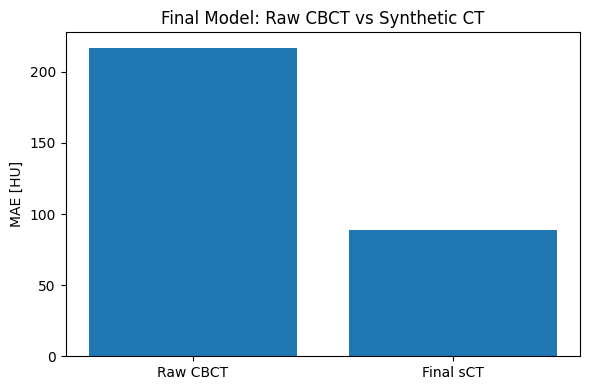

In [11]:
os.makedirs("results/figures/final_model", exist_ok=True)

plt.figure(figsize=(6, 4))
plt.bar(
    ["Raw CBCT", "Final sCT"],
    [
        final_df["raw_cbct_mae_hu"].mean(),
        final_df["sct_mae_hu"].mean()
    ]
)
plt.ylabel("MAE [HU]")
plt.title("Final Model: Raw CBCT vs Synthetic CT")
plt.tight_layout()
plt.savefig("results/figures/final_model/final_raw_vs_sct_mae.png", dpi=200)
plt.show()

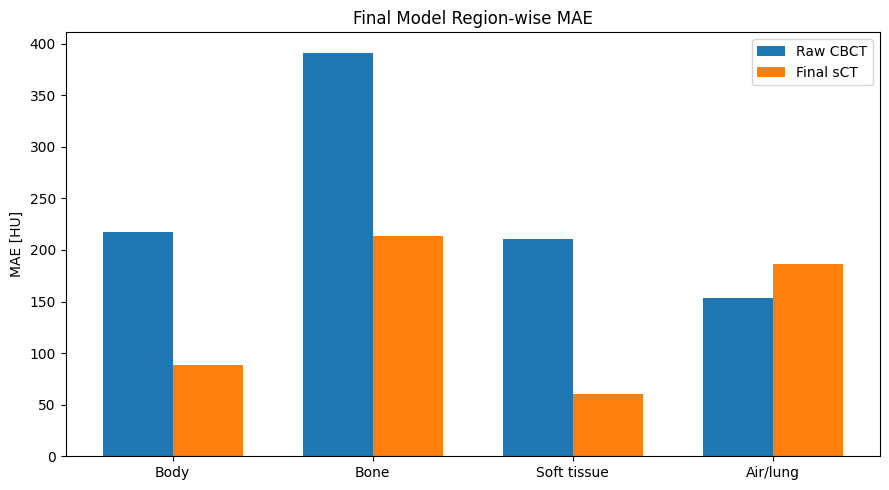

In [12]:
regions = ["body", "bone", "soft_tissue", "air_lung"]

raw_values = [
    final_df[f"raw_cbct_mae_{r}_hu"].mean()
    for r in regions
]

sct_values = [
    final_df[f"sct_mae_{r}_hu"].mean()
    for r in regions
]

x = np.arange(len(regions))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, raw_values, width, label="Raw CBCT")
plt.bar(x + width/2, sct_values, width, label="Final sCT")

plt.xticks(x, ["Body", "Bone", "Soft tissue", "Air/lung"])
plt.ylabel("MAE [HU]")
plt.title("Final Model Region-wise MAE")
plt.legend()
plt.tight_layout()

plt.savefig("results/figures/final_model/final_regionwise_mae.png", dpi=200)
plt.show()

In [13]:
def plot_final_example(sample_index, save_name):
    sample = val_dataset[sample_index]

    inputs = sample["input"].unsqueeze(0).to(device)
    targets = sample["target"].unsqueeze(0).to(device)
    masks = sample["mask"].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(inputs)

    input_center = inputs[0, 3].cpu().numpy()
    target_slice = targets[0, 0].cpu().numpy()
    pred_slice = outputs[0, 0].cpu().numpy()
    mask_slice = masks[0, 0].cpu().numpy()

    input_hu = denormalize_to_hu(input_center)
    target_hu = denormalize_to_hu(target_slice)
    pred_hu = denormalize_to_hu(pred_slice)

    raw_error = np.abs(input_hu - target_hu)
    sct_error = np.abs(pred_hu - target_hu)

    plt.figure(figsize=(24, 4))

    plt.subplot(1, 6, 1)
    plt.imshow(input_hu, cmap="gray", vmin=-1000, vmax=1000)
    plt.title("Input CBCT")
    plt.axis("off")

    plt.subplot(1, 6, 2)
    plt.imshow(target_hu, cmap="gray", vmin=-1000, vmax=1000)
    plt.title("Ground Truth CT")
    plt.axis("off")

    plt.subplot(1, 6, 3)
    plt.imshow(pred_hu, cmap="gray", vmin=-1000, vmax=1000)
    plt.title("Final sCT")
    plt.axis("off")

    plt.subplot(1, 6, 4)
    plt.imshow(raw_error, cmap="hot", vmin=0, vmax=500)
    plt.title("Raw Error")
    plt.axis("off")

    plt.subplot(1, 6, 5)
    plt.imshow(sct_error, cmap="hot", vmin=0, vmax=500)
    plt.title("sCT Error")
    plt.axis("off")

    plt.subplot(1, 6, 6)
    plt.imshow(mask_slice, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.suptitle(
        f"Patient {sample['patient_id']} | Slice {sample['slice_index']}",
        y=1.05
    )

    plt.tight_layout()
    plt.savefig(f"results/figures/final_model/{save_name}", dpi=200, bbox_inches="tight")
    plt.show()

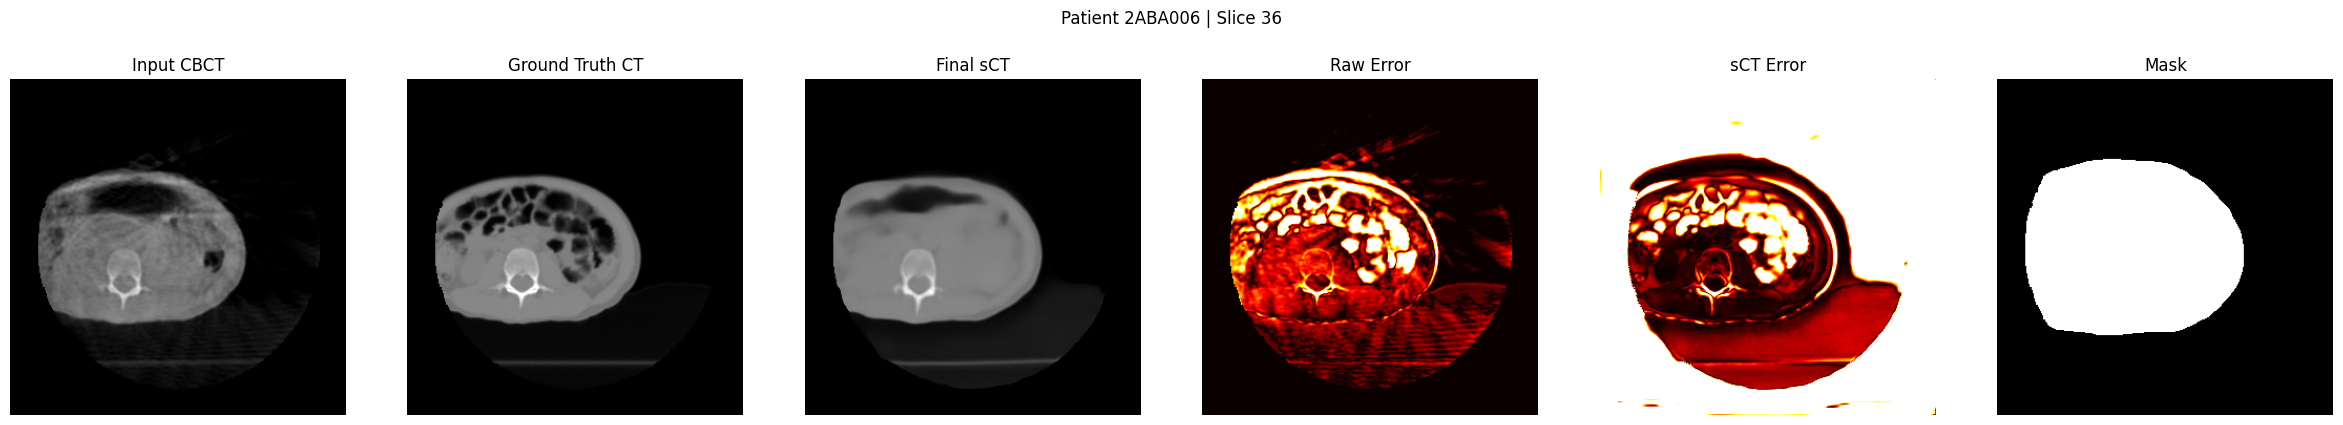

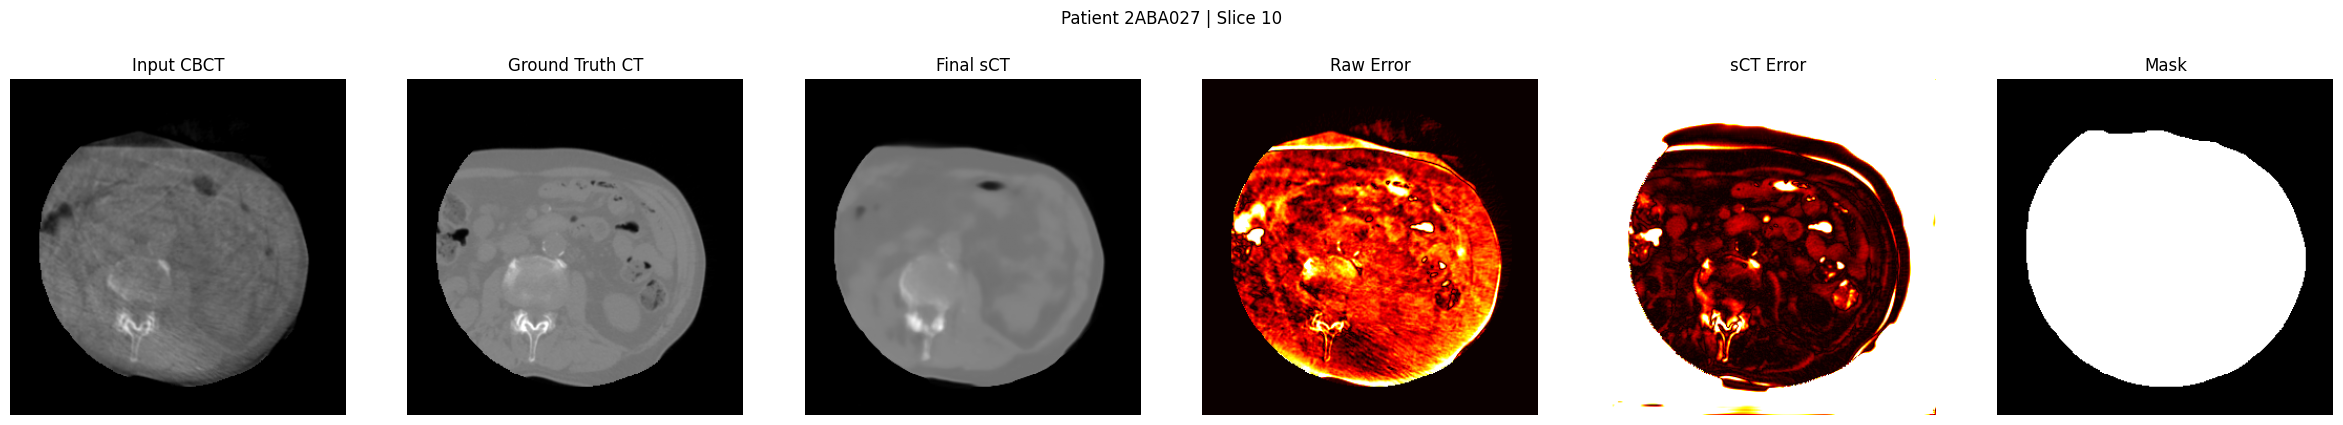

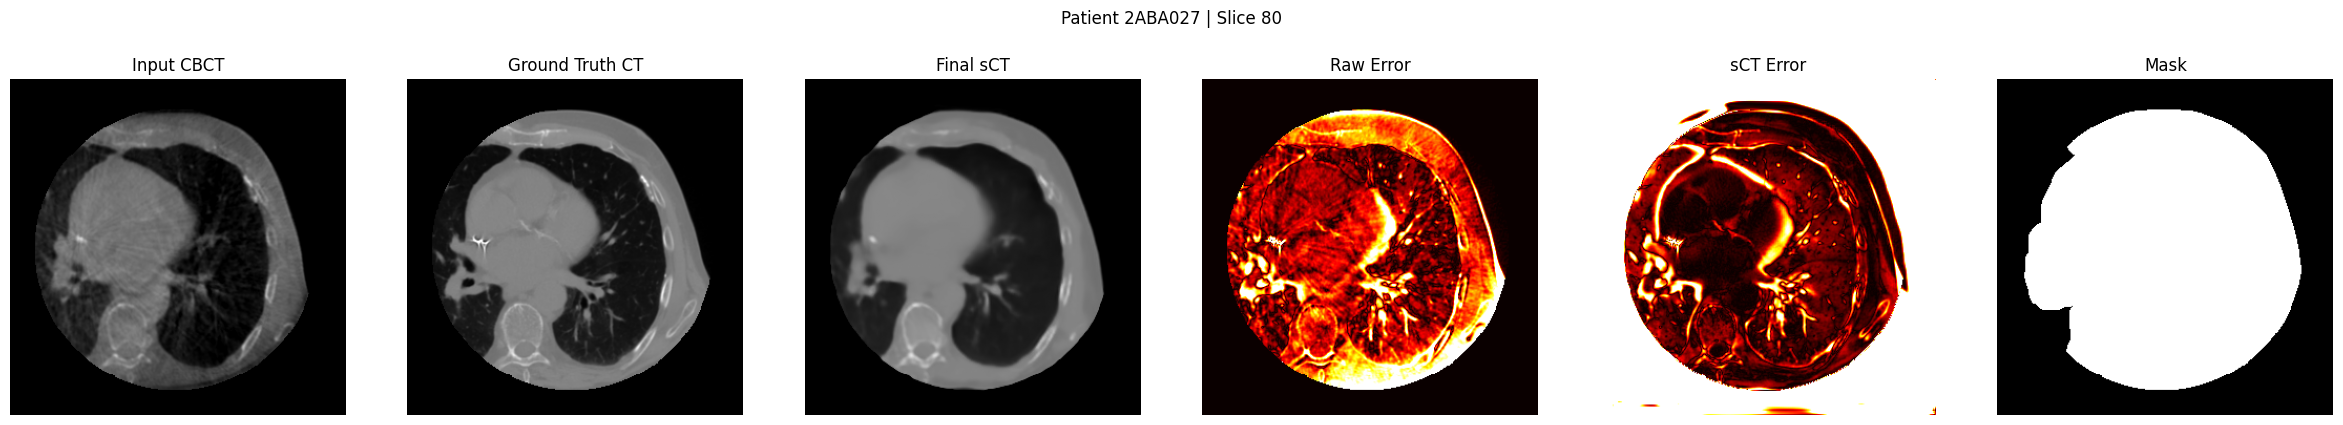

In [14]:
plot_final_example(30, "final_example_1.png")
plot_final_example(80, "final_example_2.png")
plot_final_example(150, "final_example_3.png")